In [19]:
import torch
from transformers import BertForSequenceClassification, AutoTokenizer, pipeline
import requests
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from datetime import datetime, date

# Initialize the sentiment classifier
def initialize_sentiment_analyzer():
    model = BertForSequenceClassification.from_pretrained(
        "StephanAkkerman/FinTwitBERT-sentiment",
        num_labels=3,
        id2label={0: "neutral", 1: "positive", 2: "negative"},
        label2id={"neutral": 0, "positive": 1, "negative": 2},
    )
    model.eval()

    tokenizer = AutoTokenizer.from_pretrained("StephanAkkerman/FinTwitBERT-sentiment")

    sentiment_classifier = pipeline(
        "text-classification",
        model=model,
        tokenizer=tokenizer,
        device=0 if torch.cuda.is_available() else -1,
        return_all_scores=True  # This ensures consistent output format
    )
    return sentiment_classifier

In [20]:
# Initialize the analyzer
print("Initializing sentiment analyzer...")
sentiment_classifier = initialize_sentiment_analyzer()

# Function to fetch messages from StockTwits API
def fetch_stocktwits_messages(symbol, max_messages=30):
    base_url = f"https://api.stocktwits.com/api/2/streams/symbol/{symbol}.json"
    messages = []

    try:
        print(f"Fetching messages for {symbol}...")
        response = requests.get(base_url, headers={'User-Agent': 'Mozilla/5.0'})
        response.raise_for_status()
        data = response.json()

        for msg in data.get('messages', [])[:max_messages]:
            messages.append({
                'id': msg['id'],
                'body': msg['body'],
                'created_at': msg['created_at'],
                'user': msg['user']['username']
            })

    except Exception as e:
        print(f"Error fetching messages: {e}")

    return messages

Initializing sentiment analyzer...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


In [21]:
# Function to analyze sentiment of a single message
def analyze_single_message(text):
    try:
        results = sentiment_classifier(text)
        # The pipeline returns a list of dicts for each label when return_all_scores=True
        sentiment_scores = {result['label']: result['score'] for result in results[0]}
        predicted_sentiment = max(sentiment_scores.items(), key=lambda x: x[1])[0]
        return predicted_sentiment, sentiment_scores
    except Exception as e:
        print(f"Error analyzing message: {e}")
        return "error", {'neutral': 0, 'positive': 0, 'negative': 0}
    
def analyze_messages(messages):
    results = []

    for msg in tqdm(messages, desc="Analyzing sentiment"):
        try:
            text = msg['body']
            sentiment, scores = analyze_single_message(text)

            msg['sentiment'] = sentiment
            msg.update(scores)
            results.append(msg)

        except Exception as e:
            print(f"Error processing message {msg['id']}: {e}")
            msg['sentiment'] = 'error'
            results.append(msg)

    return results

Fetching messages for TSLA...

Analyzing 30 messages...


Analyzing sentiment: 100%|██████████| 30/30 [00:03<00:00,  9.31it/s]



Sample of analyzed messages:
                   datetime       user sentiment  \
0 2025-04-23 00:45:12+00:00      IDleZ   neutral   
1 2025-04-23 00:45:08+00:00     RzCola   neutral   
2 2025-04-23 00:45:05+00:00     NPLBMF  negative   
3 2025-04-23 00:44:56+00:00  billakman  positive   
4 2025-04-23 00:44:43+00:00    Jasrich  negative   

                                                body  
0                               $SPY 5600 test $TSLA  
1              $TSLA  I guess I was pretty acccurate  
2  $DJT $TSLA \n\nThey bought all the cars. MAGA ...  
3  $TSLA JUST IN: Elon Musk says he will return t...  
4                          $TSLA rate drop coming ….  

Sentiment Distribution:
sentiment
neutral     11
negative    11
positive     8
Name: count, dtype: int64


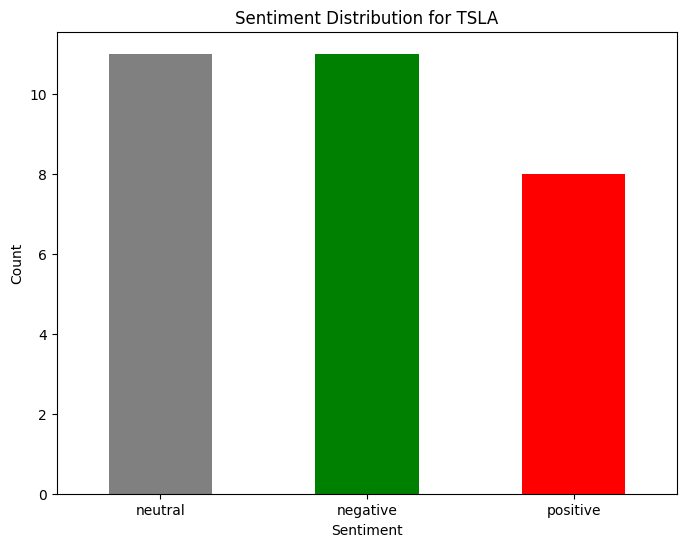

In [22]:
# Main analysis
def main():
    stock_symbol = "TSLA"  # Change to any stock symbol
    messages = fetch_stocktwits_messages(stock_symbol)

    if not messages:
        print("No messages fetched from StockTwits API")
        return

    print(f"\nAnalyzing {len(messages)} messages...")
    analyzed_messages = analyze_messages(messages)

    # Convert to DataFrame for analysis
    df = pd.DataFrame(analyzed_messages)

    # Convert created_at to datetime
    df['datetime'] = pd.to_datetime(df['created_at'])
    df['date'] = df['datetime'].dt.date

    # Show sample of results
    print("\nSample of analyzed messages:")
    print(df[['datetime', 'user', 'sentiment', 'body']].head())

    # Sentiment distribution
    sentiment_counts = df['sentiment'].value_counts()
    print("\nSentiment Distribution:")
    print(sentiment_counts)

    # Plot sentiment distribution
    plt.figure(figsize=(8, 6))
    sentiment_counts.plot(kind='bar', color=['gray', 'green', 'red'])
    plt.title(f'Sentiment Distribution for {stock_symbol}')
    plt.xlabel('Sentiment')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.show()

    # Save results
    #output_file = f'stocktwits_sentiment_{stock_symbol}.csv'
    #df.to_csv(output_file, index=False)
    #print(f"\nResults saved to {output_file}")

if __name__ == "__main__":
    main()

In [23]:
# Fetch messages + analyze sentiment
def fetch_sentiment_df(symbol="TSLA", max_messages=30):
    base_url = f"https://api.stocktwits.com/api/2/streams/symbol/{symbol}.json"
    response = requests.get(base_url, headers={'User-Agent': 'Mozilla/5.0'})
    data = response.json()
    
    rows = []
    for msg in data.get('messages', [])[:max_messages]:
        body = msg['body']
        created_at = datetime.fromisoformat(msg['created_at'].replace("Z", "+00:00")).date()
        
        scores_raw = sentiment_classifier(body)[0]
        scores = {res['label']: res['score'] for res in scores_raw}
        
        row = {
            "body": body,
            "date": created_at,
            "positive": scores.get("positive", 0),
            "neutral": scores.get("neutral", 0),
            "negative": scores.get("negative", 0),
            "net_sentiment": scores.get("positive", 0) - scores.get("negative", 0)
        }
        rows.append(row)
    
    return pd.DataFrame(rows)

# Run it
sentiment_df = fetch_sentiment_df("TSLA", max_messages=30)
sentiment_df

,body,date,positive,neutral,negative,net_sentiment
0,$SPY 5600 test $TSLA,2025-04-23,0.453277,0.494187,0.052537,0.400740
1,$TSLA I guess I was pretty acccurate,2025-04-23,0.048836,0.917416,0.033748,0.015088
2,$DJT $TSLA \n\nThey bought all the cars. MAGA ...,2025-04-23,0.176942,0.072435,0.750623,-0.573680
3,$TSLA JUST IN: Elon Musk says he will return t...,2025-04-23,0.945263,0.049110,0.005627,0.939637
4,$TSLA rate drop coming ….,2025-04-23,0.005583,0.031110,0.963306,-0.957723
5,$TSLA I guarantee every other company that mis...,2025-04-23,0.010767,0.001786,0.987447,-0.976679
6,$TSLA $BTC.X,2025-04-23,0.010630,0.985165,0.004206,0.006424
7,$NVDA $SPY $TSLA I know Chinese exporters. The...,2025-04-23,0.188107,0.105637,0.706257,-0.518150
8,$TSLA analysts working tonite,2025-04-23,0.193665,0.779773,0.026562,0.167103
9,$TSLA,2025-04-23,0.169474,0.607430,0.223096,-0.053623


In [24]:
# Aggregate daily sentiment
daily_sentiment = sentiment_df.groupby('date').agg({
    'neutral': 'mean',
    'positive': 'mean',
    'negative': 'mean'
}).reset_index()

# Add a "net sentiment" score (positive - negative)
daily_sentiment['net_sentiment'] = daily_sentiment['positive'] - daily_sentiment['negative']

daily_sentiment

,date,neutral,positive,negative,net_sentiment
0,2025-04-23,0.291361,0.303834,0.404805,-0.100971


In [25]:
import requests
import pandas as pd

API_KEY = '298089a9705e4d05b14894434eb17c25'  # Replace this with your NewsAPI key
query = "Tesla OR TSLA"        # You can modify this query
from_date = "2025-03-23"
to_date = "2025-04-22"

url = "https://newsapi.org/v2/everything"
params = {
    "q": query,
    "from": from_date,
    "to": to_date,
    "language": "en",
    "sortBy": "relevancy",
    "pageSize": 50,
    "apiKey": API_KEY
}

response = requests.get(url, params=params)
data = response.json()

# Create DataFrame
if data.get("status") == "ok":
    articles = data.get("articles", [])
    news_df = pd.DataFrame([{
        "date": article["publishedAt"],
        "title": article["title"],
        "source": article["source"]["name"],
        "url": article["url"],
        "description": article["description"]
    } for article in articles])

    print(news_df.head())
else:
    print("Error:", data.get("message"))


                   date                                              title  \
0  2025-03-25T15:52:25Z  Tesla Takedown: all the news about the protest...   
1  2025-04-22T20:18:26Z  Tesla’s revenue and profits tank amid politica...   
2  2025-04-22T22:04:19Z  Tesla is making progress on its 1950s diner an...   
3  2025-04-08T19:00:44Z  Tesla Supercharger damaged in possible explosi...   
4  2025-04-11T14:22:45Z  Tesla’s latest Cybertruck has longer range and...   

      source                                                url  \
0  The Verge  https://www.theverge.com/news/635249/tesla-tak...   
1  The Verge  https://www.theverge.com/news/653645/tesla-q1-...   
2  The Verge  https://www.theverge.com/news/653959/tesla-195...   
3  The Verge  https://www.theverge.com/news/645378/tesla-sup...   
4  The Verge  https://www.theverge.com/news/647060/tesla-cyb...   

                                         description  
0  Since early February, Tesla has been the targe...  
1  Tesla released 

In [26]:
news_df

,date,title,source,url,description
0,2025-03-25T15:52:25Z,Tesla Takedown: all the news about the protest...,The Verge,https://www.theverge.com/news/635249/tesla-tak...,"Since early February, Tesla has been the targe..."
1,2025-04-22T20:18:26Z,Tesla’s revenue and profits tank amid politica...,The Verge,https://www.theverge.com/news/653645/tesla-q1-...,Tesla released its first quarter financial ear...
2,2025-04-22T22:04:19Z,Tesla is making progress on its 1950s diner an...,The Verge,https://www.theverge.com/news/653959/tesla-195...,Tesla has shared new images of its first retro...
3,2025-04-08T19:00:44Z,Tesla Supercharger damaged in possible explosi...,The Verge,https://www.theverge.com/news/645378/tesla-sup...,A Tesla Supercharger station was severely dama...
4,2025-04-11T14:22:45Z,Tesla’s latest Cybertruck has longer range and...,The Verge,https://www.theverge.com/news/647060/tesla-cyb...,Tesla has a new entry-level Cybertruck with lo...
5,2025-03-24T22:45:53Z,The FBI launched a task force to investigate T...,The Verge,https://www.theverge.com/news/635091/fbi-tesla...,A report in the New York Post on Monday reveal...
6,2025-03-31T16:25:57Z,Elon Fiddles While Tesla Dealerships Burn,Gizmodo.com,https://gizmodo.com/elon-fiddles-while-tesla-d...,Someone set fire to a Tesla dealership in Rome...
7,2025-03-29T23:23:17Z,Crowds Turn Out Across the U.S. for ‘Tesla Tak...,Gizmodo.com,https://gizmodo.com/crowds-turn-out-across-the...,Demonstrations against Elon Musk's political i...
8,2025-04-07T21:41:23Z,It’s not looking good for Tesla’s Cybertruck r...,The Verge,https://www.theverge.com/news/644901/tesla-cyb...,Tesla’s battery range extender accessory for C...
9,2025-04-22T21:50:55Z,Elon Musk says he’ll step back from DOGE start...,The Verge,https://www.theverge.com/news/653928/elon-musk...,Elon Musk says he plans to step back from his ...


In [27]:
def analyze_sentiment_from_news_df(df):
    rows = []

    for _, row in df.iterrows():
        # Combine title + description (skip if description is NaN)
        content = f"{row['title']} {row['description']}" if pd.notna(row['description']) else row['title']
        created_at = pd.to_datetime(row['date']).date()

        scores_raw = sentiment_classifier(content)[0]
        scores = {res['label']: res['score'] for res in scores_raw}

        row_out = {
            "title": row["title"],
            "description": row.get("description", ""),
            "date": created_at,
            "source": row["source"],
            "url": row["url"],
            "positive": scores.get("positive", 0),
            "neutral": scores.get("neutral", 0),
            "negative": scores.get("negative", 0),
            "net_sentiment": scores.get("positive", 0) - scores.get("negative", 0)
        }

        rows.append(row_out)

    return pd.DataFrame(rows)


In [28]:
sentiment_news_df = analyze_sentiment_from_news_df(news_df)
sentiment_news_df

,title,description,date,source,url,positive,neutral,negative,net_sentiment
0,Tesla Takedown: all the news about the protest...,"Since early February, Tesla has been the targe...",2025-03-25,The Verge,https://www.theverge.com/news/635249/tesla-tak...,0.008297,0.002644,0.989059,-0.980762
1,Tesla’s revenue and profits tank amid politica...,Tesla released its first quarter financial ear...,2025-04-22,The Verge,https://www.theverge.com/news/653645/tesla-q1-...,0.000302,0.000285,0.999412,-0.999110
2,Tesla is making progress on its 1950s diner an...,Tesla has shared new images of its first retro...,2025-04-22,The Verge,https://www.theverge.com/news/653959/tesla-195...,0.632336,0.363928,0.003736,0.628600
3,Tesla Supercharger damaged in possible explosi...,A Tesla Supercharger station was severely dama...,2025-04-08,The Verge,https://www.theverge.com/news/645378/tesla-sup...,0.001262,0.087839,0.910899,-0.909637
4,Tesla’s latest Cybertruck has longer range and...,Tesla has a new entry-level Cybertruck with lo...,2025-04-11,The Verge,https://www.theverge.com/news/647060/tesla-cyb...,0.673584,0.238024,0.088392,0.585191
5,The FBI launched a task force to investigate T...,A report in the New York Post on Monday reveal...,2025-03-24,The Verge,https://www.theverge.com/news/635091/fbi-tesla...,0.016480,0.436211,0.547309,-0.530829
6,Elon Fiddles While Tesla Dealerships Burn,Someone set fire to a Tesla dealership in Rome...,2025-03-31,Gizmodo.com,https://gizmodo.com/elon-fiddles-while-tesla-d...,0.001684,0.313041,0.685276,-0.683592
7,Crowds Turn Out Across the U.S. for ‘Tesla Tak...,Demonstrations against Elon Musk's political i...,2025-03-29,Gizmodo.com,https://gizmodo.com/crowds-turn-out-across-the...,0.011850,0.296095,0.692055,-0.680205
8,It’s not looking good for Tesla’s Cybertruck r...,Tesla’s battery range extender accessory for C...,2025-04-07,The Verge,https://www.theverge.com/news/644901/tesla-cyb...,0.010758,0.034786,0.954456,-0.943698
9,Elon Musk says he’ll step back from DOGE start...,Elon Musk says he plans to step back from his ...,2025-04-22,The Verge,https://www.theverge.com/news/653928/elon-musk...,0.567755,0.405871,0.026374,0.541381


In [29]:
# Aggregate daily sentiment
daily_sentiment = sentiment_news_df.groupby('date').agg({
    'neutral': 'mean',
    'positive': 'mean',
    'negative': 'mean'
}).reset_index()

# Add a "net sentiment" score (positive - negative)
daily_sentiment['net_sentiment'] = daily_sentiment['positive'] - daily_sentiment['negative']

daily_sentiment

,date,neutral,positive,negative,net_sentiment
0,2025-03-24,0.436211,0.016480,0.547309,-0.530829
1,2025-03-25,0.040912,0.388236,0.570852,-0.182615
2,2025-03-26,0.051900,0.885541,0.062560,0.822981
3,2025-03-27,0.120642,0.002181,0.877177,-0.874996
4,2025-03-28,0.090883,0.160014,0.749104,-0.589090
5,2025-03-29,0.296095,0.011850,0.692055,-0.680205
6,2025-03-30,0.896390,0.008725,0.094885,-0.086160
7,2025-03-31,0.216333,0.005389,0.778278,-0.772889
8,2025-04-02,0.000102,0.000138,0.999759,-0.999621
9,2025-04-03,0.174104,0.198202,0.627694,-0.429492
